# Exploring the Power of Predictive Tools in Credit Instruments  

__Research motivation:__</u>

Debt, being the biggest source of income, capital, and socio-economic issues on earth, our research would consist of exploring whether financial institutions’ credit scoring is an efficient way of predicting default probability and whether we can use borrowers’ personal information such as number of accounts, credit score/grade, interest rate, and types of loan to predict the likeliness of default (probability), the severity/recovery of default, and explore whether there are relationships between variables within our dataset.

__Proposed dataset__:</u>

[Loan Default prediction dataset](https://www.kaggle.com/datasets/hemanthsai7/loandefault), a dataset created by Deloitte, as part of MachineHack, has created a
training dataset of 67,463 rows and 35 columns and a testing dataset of 28,913 rows and 34 columns. The
hackathon demands a few pre-requisite skills like big dataset, underfitting vs overfitting, and the ability to
optimise “log_loss” to generalise well on unseen data.

__Techniques used__:</u>

>• Principal Component Analysis. 

>• Multiple Linear Regression. 

>• Evaluating Predictive Performance. 

>• Credit Risk Detection and Prediction.

Below is our training dataset which will serve to visualize our dataset as well as build our predictive model. 

In [5]:
# Upload the dataset
df <- read.csv("research_train.csv")
df <- na.omit(df)
df

ID,Loan.Amount,Funded.Amount,Funded.Amount.Investor,Term,Batch.Enrolled,Interest.Rate,Grade,Sub.Grade,Employment.Duration,...,Recoveries,Collection.Recovery.Fee,Collection.12.months.Medical,Application.Type,Last.week.Pay,Accounts.Delinquent,Total.Collection.Amount,Total.Current.Balance,Total.Revolving.Credit.Limit,Loan.Status
65087372,10000,32236,12329.363,59,BAT2522922,11.135007,B,C4,MORTGAGE,...,2.498291e+00,0.7937238,0,INDIVIDUAL,49,0,31,311301,6619,0
1450153,3609,11940,12191.997,59,BAT1586599,12.237563,C,D3,RENT,...,2.377215e+00,0.9748211,0,INDIVIDUAL,109,0,53,182610,20885,0
1969101,28276,9311,21603.225,59,BAT2136391,12.545884,F,D4,MORTGAGE,...,4.316277e+00,1.0200750,0,INDIVIDUAL,66,0,34,89801,26155,0
6651430,11170,6954,17877.156,59,BAT2428731,16.731201,C,C3,MORTGAGE,...,1.070203e-01,0.7499710,0,INDIVIDUAL,39,0,40,9189,60214,0
14354669,16890,13226,13539.927,59,BAT5341619,15.008300,C,D4,MORTGAGE,...,1.294819e+03,0.3689529,0,INDIVIDUAL,18,0,430,126029,22579,0
50509046,34631,30203,8635.932,36,BAT4694572,17.246986,B,G5,RENT,...,5.043575e+00,0.5816877,0,INDIVIDUAL,32,0,42,51252,27480,0
32737431,30844,19773,15777.512,59,BAT4808022,10.731432,C,C5,RENT,...,3.167937e+00,0.5530764,0,INDIVIDUAL,71,0,3388,42069,31068,0
63151650,20744,10609,7645.015,58,BAT2558388,13.993688,A,A5,OWN,...,9.844800e-02,0.0475891,0,INDIVIDUAL,87,0,48,184909,43303,0
4279662,9299,11238,13429.457,59,BAT5341619,11.178457,G,C2,MORTGAGE,...,5.302136e-01,0.2169853,0,INDIVIDUAL,144,0,26,68126,7482,0
4431034,19232,8962,7004.097,58,BAT2078974,5.520413,C,B5,RENT,...,2.912215e+00,0.8868644,0,INDIVIDUAL,9,0,35,71650,14871,0


As presented in the dataset above, we have more than 34 variables for each issued loan which may lead us to create a model that is overcomplicated and inefficient. 

As such, Principal Component Analysis, a technique used to simplify a dataset by finding the most important patterns in the data, may enable us to better understand our dataset. 


In [6]:
# Factorize categorical data

df[,c(6,8:10,12:14,23,29)] <- lapply(df[,c(6,8:10,12:14,23,29)], factor)

# Run a PCA on it

pcs <- prcomp(df[, which(sapply(df, is.numeric))])
summary(pcs)


Importance of components:
                            PC1      PC2   PC3   PC4  PC5  PC6  PC7  PC8  PC9
Standard deviation     21091554 1.39e+05 45028 20917 8367 8153 7832 6783 2222
Proportion of Variance        1 4.00e-05     0     0    0    0    0    0    0
Cumulative Proportion         1 1.00e+00     1     1    1    1    1    1    1
                        PC10 PC11  PC12  PC13  PC14  PC15  PC16  PC17  PC18
Standard deviation     744.3  357 43.31 22.53 8.452 8.305 6.223 5.243 3.717
Proportion of Variance   0.0    0  0.00  0.00 0.000 0.000 0.000 0.000 0.000
Cumulative Proportion    1.0    1  1.00  1.00 1.000 1.000 1.000 1.000 1.000
                        PC19  PC20   PC21  PC22   PC23   PC24   PC25      PC26
Standard deviation     3.489 3.324 0.8006 0.473 0.3464 0.2896 0.1443 2.107e-09
Proportion of Variance 0.000 0.000 0.0000 0.000 0.0000 0.0000 0.0000 0.000e+00
Cumulative Proportion  1.000 1.000 1.0000 1.000 1.0000 1.0000 1.0000 1.000e+00

Based on results of our PCA, it appears that the categorical nature of our dataset is hard to capture using PCA techniques. Hence, we will be individually exploring the relationships of each independent variable with our main dependent variable namely __loan.status__ (1 for defaults and 0 for non-default). 

## Initial Regression

We ran a preliminary regression model to help us explore the dataset and find any potential significances.

In [4]:
# Frame the variables
lm.df <- data.frame(df[,2:35])

# Identify factors with only one level
levels_df <- data.frame(sapply(lm.df, function(x) length(unique(x))))
one_level_factors <- c("Accounts.Delinquent", "Payment.Plan")
print(one_level_factors)

# Remove factors with only one level
lm.df2 <- lm.df[, !names(lm.df) %in% one_level_factors]

# Run the regression on the updated data
train.lm <- lm(Loan.Status~., data=lm.df2)

summary(train.lm)

[1] "Accounts.Delinquent" "Payment.Plan"       



Call:
lm(formula = Loan.Status ~ ., data = lm.df2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.51110 -0.09984 -0.08971 -0.07842  0.97122 

Coefficients:
                                       Estimate Std. Error t value Pr(>|t|)   
(Intercept)                           7.908e-02  8.078e-02   0.979  0.32758   
Loan.Amount                          -1.385e-07  1.337e-07  -1.036  0.30007   
Funded.Amount                         3.278e-08  1.371e-07   0.239  0.81100   
Funded.Amount.Investor               -1.194e-08  1.647e-07  -0.072  0.94224   
Term                                 -2.406e-04  3.360e-04  -0.716  0.47392   
Batch.EnrolledBAT1135695              2.322e-02  1.768e-02   1.314  0.18891   
Batch.EnrolledBAT1184694             -1.657e-02  8.047e-03  -2.059  0.03949 * 
Batch.EnrolledBAT1467036             -9.307e-03  1.153e-02  -0.807  0.41957   
Batch.EnrolledBAT1586599              4.520e-03  7.409e-03   0.610  0.54177   
Batch.EnrolledBAT1761981              2

As seen above, our regression model resulted in tens of coefficients since we had a lot of categorical variables. Furthermore, it appears that there's not much significance in the regression we just ran. 

Therefore, it will be more interesting to explore the data on individual variable basis and find inference.

## Correlation matrix

First, let us explore the correlation existing between our variables.

In [7]:
# Use sapply and is.numeric to identify numeric columns
numtrain <- sapply(df, is.numeric)

# Subset the data frame using the logical vector
numtrain <- df[, numtrain]

#Correlation matrix
cor(numtrain)


Warning message in cor(numtrain):
"the standard deviation is zero"

,ID,Loan.Amount,Funded.Amount,Funded.Amount.Investor,Term,Interest.Rate,Home.Ownership,Debit.to.Income,Delinquency...two.years,Inquires...six.months,...,Total.Received.Late.Fee,Recoveries,Collection.Recovery.Fee,Collection.12.months.Medical,Last.week.Pay,Accounts.Delinquent,Total.Collection.Amount,Total.Current.Balance,Total.Revolving.Credit.Limit,Loan.Status
ID,1.0000000000,-3.480496e-03,-0.0033023487,2.953856e-03,0.0032263257,0.004258261,-0.004390262,-0.0105780739,0.0005683304,-0.0066279672,...,6.673652e-03,-0.0014353889,-0.0018020907,-0.0028997317,0.0009071142,NA,0.0037446284,-0.0035719590,-0.0051405551,4.717844e-04
Loan.Amount,-0.0034804956,1.000000e+00,-0.0005512067,2.830856e-03,0.0042773512,-0.004887921,0.016690550,0.0079589505,-0.0004686547,0.0089616528,...,-3.386008e-05,-0.0016063407,-0.0021423485,-0.0027262816,-0.0023621086,NA,-0.0041352736,-0.0082851506,0.0022892546,-4.472955e-03
Funded.Amount,-0.0033023487,-5.512067e-04,1.0000000000,1.022748e-02,-0.0015034308,0.002310039,-0.003517682,0.0023467061,0.0113134093,-0.0015868625,...,1.541903e-03,0.0004617280,0.0001746705,0.0010708114,-0.0034756939,NA,-0.0028211614,-0.0014990859,0.0061448523,1.364110e-03
Funded.Amount.Investor,0.0029538563,2.830856e-03,0.0102274750,1.000000e+00,-0.0089428093,-0.001916952,0.001338717,0.0001118111,0.0019246654,-0.0030731072,...,-2.319540e-04,0.0009661699,-0.0072721030,0.0018142680,0.0042481858,NA,0.0068623887,0.0032832856,0.0056687766,-9.097431e-05
Term,0.0032263257,4.277351e-03,-0.0015034308,-8.942809e-03,1.0000000000,-0.012687921,-0.021813442,0.0010264432,-0.0044938056,-0.0052720085,...,-7.356424e-04,-0.0034750385,-0.0012029204,-0.0032634073,0.0070346694,NA,0.0003579106,0.0033614327,-0.0050679224,-3.409719e-03
Interest.Rate,0.0042582612,-4.887921e-03,0.0023100393,-1.916952e-03,-0.0126879211,1.000000000,0.005467084,-0.0112033964,0.0040448049,0.0091722886,...,3.118960e-03,0.0093478549,0.0012809307,-0.0098945236,-0.0126519050,NA,0.0027710887,-0.0025671272,0.0166512125,2.899848e-03
Home.Ownership,-0.0043902619,1.669055e-02,-0.0035176824,1.338717e-03,-0.0218134423,0.005467084,1.000000000,0.0227812703,-0.0037928387,0.0050239846,...,4.010521e-03,0.0043985347,-0.0038206423,-0.0026389462,-0.0045733733,NA,0.0063142635,0.0071173179,0.0050083071,3.715769e-03
Debit.to.Income,-0.0105780739,7.958951e-03,0.0023467061,1.118111e-04,0.0010264432,-0.011203396,0.022781270,1.0000000000,-0.0040074989,0.0022463336,...,-1.022415e-02,-0.0096927016,0.0021995878,-0.0007156618,0.0086392741,NA,0.0015553752,-0.0115823019,-0.0072362909,-3.057323e-03
Delinquency...two.years,0.0005683304,-4.686547e-04,0.0113134093,1.924665e-03,-0.0044938056,0.004044805,-0.003792839,-0.0040074989,1.0000000000,0.0146785534,...,7.942519e-03,0.0173483358,0.0027069787,0.0034505276,0.0011596709,NA,0.0056416633,0.0026023585,0.0093145217,9.990339e-03
Inquires...six.months,-0.0066279672,8.961653e-03,-0.0015868625,-3.073107e-03,-0.0052720085,0.009172289,0.005023985,0.0022463336,0.0146785534,1.0000000000,...,8.295616e-03,0.0124873845,0.0083876498,-0.0044355685,-0.0044534774,NA,-0.0022097283,0.0015311474,0.0046780585,5.782365e-04


__Conclusion:__ It appears that correlation levels between all of our variables are almost insignificant (very close to zero).

## Loan Batches 

Are loans bacthed on an interest rate basis and do any batches default more on average than others. Using a simple agreggation, we dind the following.

In [8]:
# aggregate by name and calculate mean scores for each exam
Batches <- aggregate(cbind(Interest.Rate, Loan.Status) ~ Batch.Enrolled, df, mean)

# rename the aggregated columns
colnames(Batches)[2:3] <- c("Mean.Interest", "Mean.Default")

Batches

Batch.Enrolled,Mean.Interest,Mean.Default
BAT1104812,11.91945,0.09979973
BAT1135695,11.76151,0.12500000
BAT1184694,12.00928,0.08355091
BAT1467036,11.81416,0.09102244
BAT1586599,11.81724,0.10502864
BAT1761981,11.65902,0.10402685
BAT1766061,11.83947,0.08487337
BAT1780517,11.75815,0.09945901
BAT1930365,11.77778,0.09490239
BAT2003848,12.00249,0.10807601


From the above, it appears that all batches are similar as their average interest rates and default rate is very close.

## Loan Grades 

We did the same for loan grades.

In [9]:
# aggregate by name and calculate mean scores for each exam
Grade <- aggregate(cbind(Interest.Rate, Loan.Status) ~ Grade, df, mean)

# rename the aggregated columns
colnames(Grade)[2:3] <- c("Mean.Interest", "Mean.Default")

Grade

Grade,Mean.Interest,Mean.Default
A,11.90140,0.09124844
B,11.73877,0.08723722
C,11.87044,0.09389573
D,11.84101,0.09637971
E,11.92373,0.09587341
F,11.96828,0.10373998
G,12.09757,0.10634921


Opposing to what normally grades are for, it appears that all batches are similar as their average interest rates and default rate is very close. Hence, they may not be very relevant in building our model.

## Employment Duration

We did the same for employment duration.

In [10]:
# aggregate by name and calculate mean scores for each exam
ED <- aggregate(cbind(Interest.Rate, Loan.Status) ~ Employment.Duration, df, mean)

# rename the aggregated columns
colnames(ED)[2:3] <- c("Mean.Interest", "Mean.Default")

ED

Employment.Duration,Mean.Interest,Mean.Default
MORTGAGE,11.79428,0.08866331
OWN,11.92872,0.10155128
RENT,11.90073,0.09569358


It appears that the different employment duration and in this case represented by real estate ownership may have an impact on defaul status with estate owners most likely to default and still under mortgage least likely.

## Loan Amount 

Since the loan amount variable is numeric, we will be using scatterplots to visualize the data.

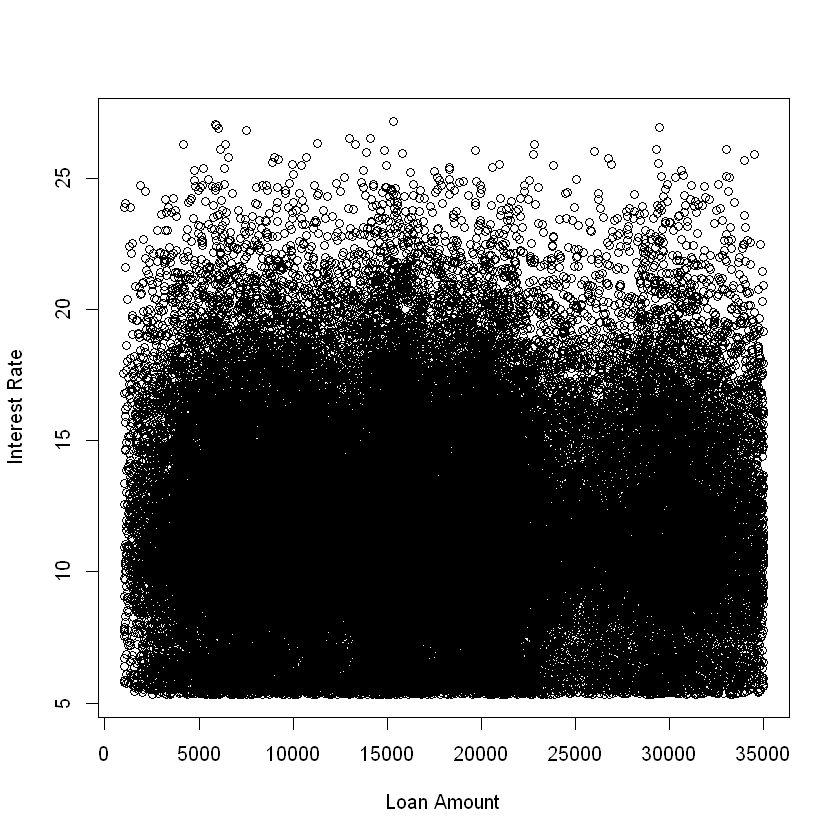

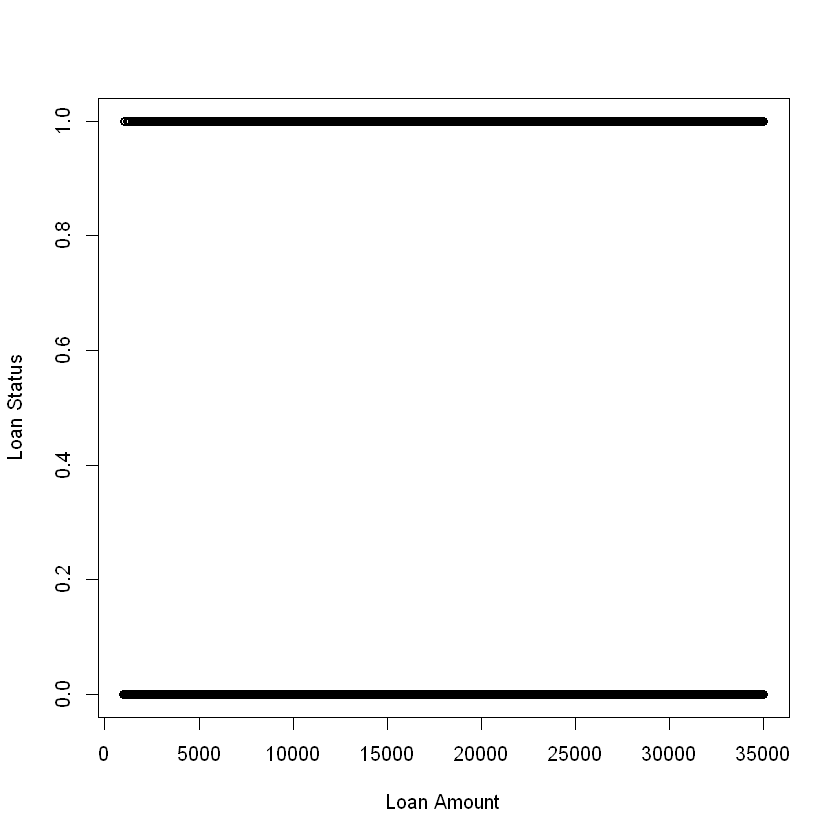

In [11]:
# create a scatterplot of Loan.Amount vs. Interest.Rate
p1 <- plot(df$Loan.Amount, rtrain$Interest.Rate, xlab = "Loan Amount", ylab = "Interest Rate")

# create a scatterplot of Loan.Amount vs. Loan.Default
p2 <- plot(df$Loan.Amount, rtrain$Loan.Status, xlab = "Loan Amount", ylab = "Loan Status")

Hence, it appears that loan amounts do not impact interest rate or loan default rate. 

__Conclusion__: In our research, we will keep on investigating the relationship between our dependent and other variables.

## Initial Prediction Model

We will train an initial model and use our testing set to determine its accuracy. Throughout our research, our ambition would be to improve the accuracy of the trained model. 

In [12]:
# Split the data into training and testing sets
set.seed(123)
train_index <- sample(1:nrow(df), 0.7 * nrow(df))
train_data <- df[train_index, ]
test_data <- df[-train_index, ]

# Fit a logistic regression model
model <- glm(Loan.Status ~ Loan.Amount + Interest.Rate + Employment.Duration, data = df, family = binomial())

# Make predictions on the test data
predictions <- predict(model, newdata = test_data, type = "response")

# Evaluate the model performance
pred <- prediction(predictions, test_data$Loan.Status)
perf <- performance(pred, measure = "tpr", x.measure = "fpr")
plot(perf, main = "ROC Curve")

ERROR: Error in prediction(predictions, test_data$Loan.Status): could not find function "prediction"


## Results: 

Since, we couldn't load some of the packages on Jupyter, find the details of our code in the R file.